### Block 1: Import necessary libraries

In [80]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, circuit_drawer
from qiskit_aer import Aer
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import BackendEstimatorV2
from qiskit.circuit import ClassicalRegister
import numpy as np

### Block 2: Define the QET circuit function

In [131]:
def qet_circuit(h, k, apply_h):
    """
    Constructs the quantum circuit for the QET experiment.

    Args:
      h: Parameter h for the Hamiltonian.
      k: Parameter k for the Hamiltonian.

    Returns:
      qc: The constructed QuantumCircuit object.
    """

    qc = QuantumCircuit(2, 2)

    # Prepare the ground state
    theta = -np.arccos(
        (1 / np.sqrt(2)) * np.sqrt(1 - h / np.sqrt(h**2 + k**2))
    )
    qc.ry(2 * theta, 0)
    qc.cx(0, 1)

    # Bob's conditional operation
    phi = np.arcsin(
        (h * k) / np.sqrt((h**2 + 2 * k**2)**2 + h**2 * k**2)
    ) / 2

    # Bob's conditional operation
    qc.cry(2 * phi, 0, 1).c_if(0, 0)  # Apply U(+1) if classical bit 0 is 0
    qc.cry(-2 * phi, 0, 1).c_if(0, 1)  # Apply U(-1) if classical bit 0 is 1

    qc.h(0)

    if apply_h:
      qc.h(1)

    # Alice's measurement
    qc.measure(0, 0)  # Measure qubit 0 into classical bit 0
    qc.measure(1, 1)  # Measure qubit 1 into classical bit 1

    return qc

### Block 3: Simulation

In [132]:
# Choose parameters
h = 1
k = 0.5

total_shots = 2 ** 10

def run_sim(v):
    # Construct the circuit
    qc = qet_circuit(h, k, v)

    # Use the Qiskit simulator
    simulator = Aer.get_backend('qasm_simulator')
    qc_compiled = transpile(qc, simulator)

    job_sim = simulator.run(qc_compiled, shots=total_shots)
    result_sim = job_sim.result()
    counts_sim = result_sim.get_counts(qc_compiled)

    return qc, counts_sim

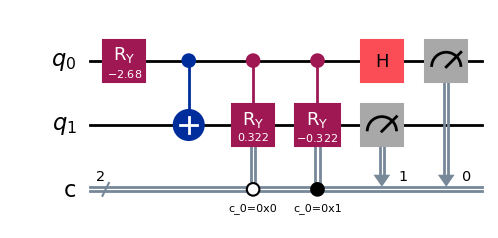

In [133]:
qc, h1_counts_sim = run_sim(False)
circuit_drawer(qc, output='mpl')

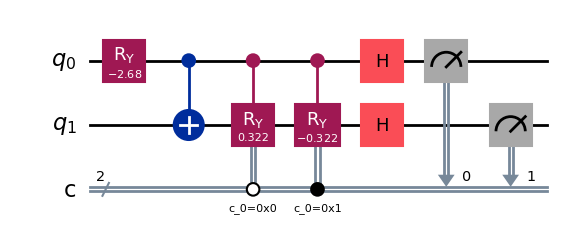

In [134]:
qc, v_counts_sim = run_sim(True)
circuit_drawer(qc, output='mpl')

#### Block 3.1: Plot simulation results

H1 Simulation results:
{'01': 31, '00': 17, '10': 507, '11': 469}


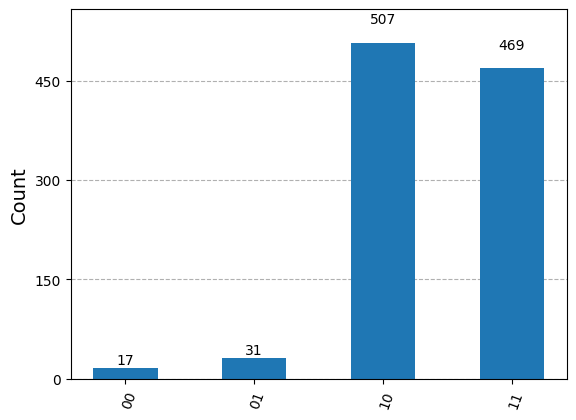

In [135]:
# Print and plot results
print("H1 Simulation results:")
print(h1_counts_sim)
plot_histogram(h1_counts_sim)

V Simulation results:
{'11': 133, '10': 389, '00': 145, '01': 357}


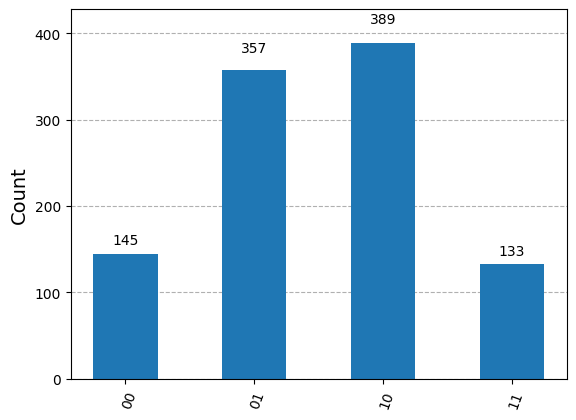

In [136]:
print("V Simulation results:")
print(v_counts_sim)
plot_histogram(v_counts_sim)

### Block 4: Execution on real quantum hardware

#### Block 4.1: Build `h1` circuit

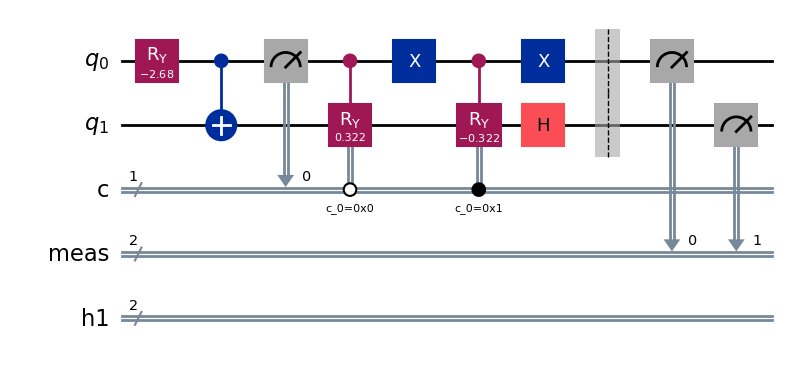

In [ ]:
h1 = SparsePauliOp.from_list([("ZI", h), ("II", h**2 / np.sqrt(h**2 + k**2))])

qc_h1 = qet_circuit(h, k)
cr_h1 = ClassicalRegister(h1.num_qubits, 'h1')
qc_h1.add_register(cr_h1)
# Apply gates for H_1 measurement
for pauli, coeff in h1.to_list():
    if pauli == "Z":
        qc_h1.z(0)  # Apply Z gate to qubit 0
    # Add other cases for different Pauli terms if needed

circuit_drawer(qc_h1, output='mpl')

#### Block 4.2: Build `v` circuit

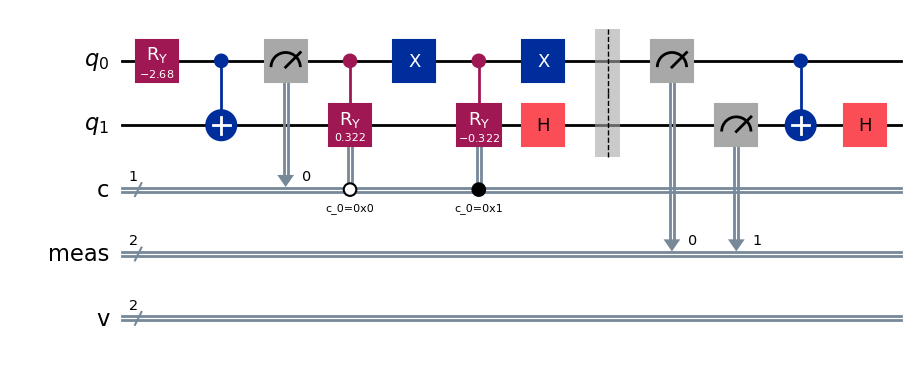

In [31]:
v = SparsePauliOp.from_list([("XX", 2 * k), ("II", 2 * k**2 / np.sqrt(h**2 + k**2))])

qc_v = qet_circuit(h, k)
cr_v = ClassicalRegister(v.num_qubits, 'v')
qc_v.add_register(cr_v)  # Add the ClassicalRegister
# Apply gates for V measurement
for pauli, coeff in v.to_list():
    if pauli == "XX":
        qc_v.cx(0, 1)  # Apply CX gate for XX
        qc_v.h(1)  # Apply Hadamard for measurement in X basis
    # Add other cases for different Pauli terms if needed

circuit_drawer(qc_v, output='mpl')

#### Block 4.3: Execute

In [69]:
# Choose IBM Quantum backend
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.backend('ibm_brisbane')

# Use Estimator to get expectation values
estimator = BackendEstimatorV2(backend=backend)  # Initialize Estimator

In [ ]:
# Execute the circuits and get expectation values
qc_h1_transpiled = transpile(qc_h1, backend)
num_qubits_transpiled = qc_h1_transpiled.num_qubits
h1_expanded = SparsePauliOp.from_list([("Z" + "I" * (num_qubits_transpiled - 1), h),
                                     ("I" * num_qubits_transpiled, h**2 / np.sqrt(h**2 + k**2))])
pub_h1 = (qc_h1_transpiled, [h1_expanded], None)
job_h1 = estimator.run([pub_h1])
result_h1 = job_h1.result()

In [68]:
qc_v_transpiled = transpile(qc_v, backend)
num_qubits_transpiled = qc_v_transpiled.num_qubits
v_expanded = SparsePauliOp.from_list([("XX" + "I" * (num_qubits_transpiled - 2), 2 * k),
                                     ("I" * num_qubits_transpiled, 2 * k**2 / np.sqrt(h**2 + k**2))])
pub_v = (qc_v_transpiled, [v_expanded], None)
job_v = estimator.run([pub_v])
result_v = job_v.result()

/home/amir/Documents/git/quantum/ibm/.venv/lib/python3.12/site-packages/qiskit_ibm_runtime/ibm_backend.py:727: UserWarning: The backend ibm_kyiv is currently paused.
  warnings.warn(f"The backend {self.name} is currently paused.")


RuntimeInvalidStateError: 'Unable to retrieve result for job cwskk2w997wg008xk7bg. Job was cancelled.'

In [ ]:
expectation_value_h1 = result_h1._pub_results[0].data.values()
expectation_value_v = result_v._pub_results[0].data.values()

# Print expectation values
print("Expectation value of H_1:", expectation_value_h1)
print("Expectation value of V:", expectation_value_v)

#######################################################
# job_real = assemble(qc_compiled, shots=1024)

# # Execute on the backend
# result_real = backend.run(job_real).result()
# counts_real = result_real.get_counts(qc_compiled)

# # Print and plot results
# print("Real quantum computer results:")
# print(counts_real)
# plot_histogram(counts_real)

Expectation value of H_1: dict_values([array([1.85682953]), array([0.00424419])])


### Block 5: Analyze the results

In [137]:
# This is <H1>
z_expectation = 0
xx_expectation = 0

for key, count in h1_counts_sim.items():
    if key[1] == '0':  # Check the second bit for <H1>
        z_expectation += count
    else:
        z_expectation -= count

for key, count in v_counts_sim.items():
    if key in ('11', '00'):
        xx_expectation += count
    else:
        xx_expectation -= count

z_expectation /= total_shots
xx_expectation /= total_shots

E1 = z_expectation + xx_expectation

print(f'<H1> = {z_expectation}\t<V> = {xx_expectation}\t<E1> = {E1}')

<H1> = 0.0234375	<V> = -0.45703125	<E1> = -0.43359375
